In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Technical Content/data/kenya.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [7]:
df["Country"] = "Kenya"
df["date"] = pd.to_datetime(
df["YEAR"]*1000 + df["DOY"],
format="%Y%j"
)
df["Month"] = df["date"].dt.month

In [8]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


The Kenya dataset contains daily climate observations from 2015 to 2026, including temperature, precipitation, humidity, and wind variables. The data allows for analysis of seasonal patterns, climate variability, and extreme events relevant to understanding climate risks in East Africa.

In [9]:
df.to_csv("/content/drive/MyDrive/kenya_clean.csv", index=False)

In [10]:
print("Missing values:")
print(df.isna().sum().sum())
print("Duplicates:")
print(df.duplicated().sum())

Missing values:
0
Duplicates:
0


No missing values or duplicate records were found in the Kenya dataset, indicating high data quality. Therefore, no rows were removed, and the dataset is suitable for further analysis.

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


The Kenya dataset shows a moderately warm and stable climate over the 2015–2026 period. The mean daily temperature is approximately 20.4°C, with relatively low variability (standard deviation ≈ 1.44°C), indicating that temperature conditions are fairly consistent throughout the year. Maximum temperatures reach up to 34.27°C, suggesting that extreme heat events are possible but not frequent.

Rainfall patterns, however, show a different behavior. The mean daily precipitation is 1.47 mm, but the median is much lower (0.38 mm), indicating a strongly skewed distribution. This means that most days experience little to no rainfall, while a small number of days receive very high precipitation (maximum ≈ 51.65 mm). Such variability highlights the presence of occasional heavy rainfall events.

Relative humidity averages around 65.8%, indicating generally moist atmospheric conditions, although it varies significantly across the year. Wind speeds remain moderate, with average values around 3.06 m/s, suggesting no extreme wind-related climate patterns.

In [12]:
(df["T2M_MAX"] > 35).sum()

np.int64(0)

Kenya recorded zero days with temperatures exceeding 35°C during the study period. This indicates that extreme heat events are rare or absent in this region. Compared to countries such as Sudan or Nigeria, Kenya exhibits a much lower exposure to heat stress.

This suggests that temperature extremes are not the primary climate risk in Kenya. Instead, climate vulnerability is more likely driven by rainfall variability and drought conditions.

In [17]:
from scipy.stats import zscore
import numpy as np

cols = ['T2M','PRECTOTCORR']
z = np.abs(zscore(df[cols]))
(z > 3).sum()

np.int64(100)

Outliers were retained in the dataset because they likely represent real extreme weather events rather than data errors. Since the analysis focuses on climate variability and extremes, removing these values would reduce the ability to capture meaningful climate risks.

In [21]:
import matplotlib.pyplot as plt

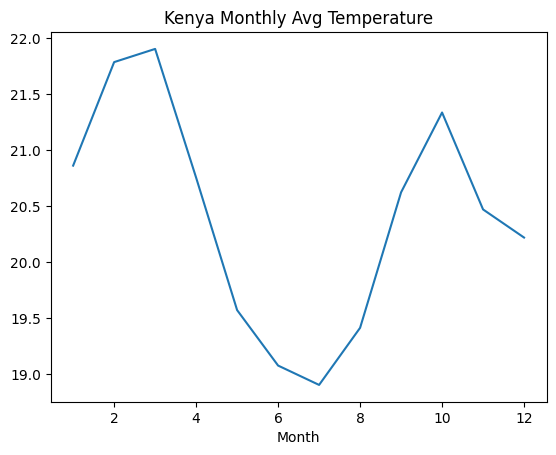

In [22]:
df.groupby('Month')['T2M'].mean().plot()
plt.title("Kenya Monthly Avg Temperature")
plt.show()

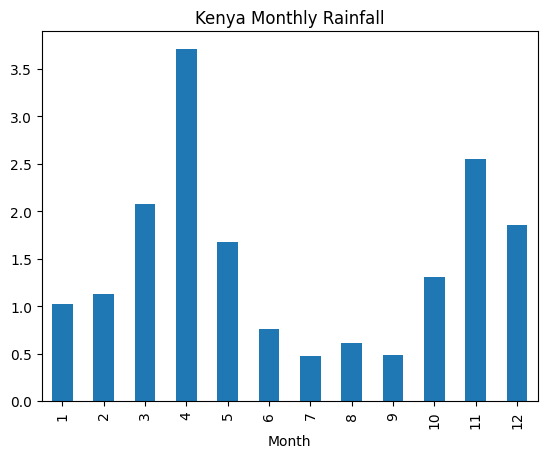

In [23]:
df.groupby('Month')['PRECTOTCORR'].mean().plot(kind='bar')
plt.title("Kenya Monthly Rainfall")
plt.show()

The rainfall distribution is highly right-skewed, with most days experiencing little to no rainfall and a small number of days experiencing heavy precipitation. This confirms that Kenya has frequent dry days interrupted by occasional intense rainfall events.

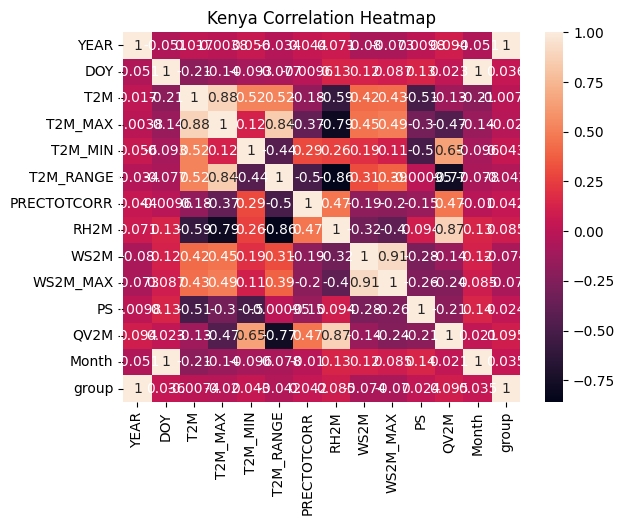

In [27]:
import seaborn as sns
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Kenya Correlation Heatmap")
plt.show()

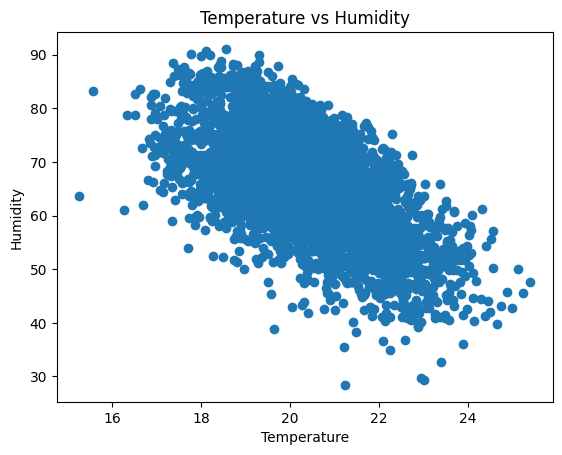

In [29]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")
plt.show()

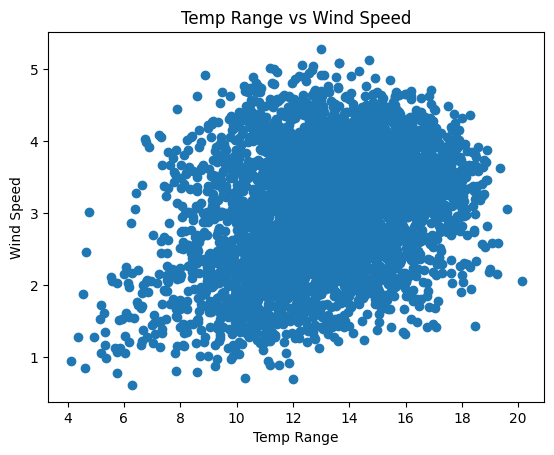

In [30]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temp Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind Speed")
plt.show()

In [13]:
df["dry"] = df["PRECTOTCORR"] < 1

In [14]:
df["group"] = (df["dry"] != df["dry"].shift()).cumsum()

In [15]:
streaks = df[df["dry"]].groupby("group").size()

In [16]:
streaks.max()

56

The longest consecutive dry period in Kenya lasted 56 days, indicating prolonged periods without rainfall. This highlights the country’s exposure to drought conditions, particularly outside the main rainy seasons.